# tmp — nov24

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.fighelper import *
from vae.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from analysis.chosen import *
from figures.analysis import *
from figures.imgs import plot_weights

device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

In [3]:
from base.distributions import Poisson, Normal

In [7]:
prior_rate = 10
conditional_mean = 4
conditional_sigma = 2

prior = Poisson(
    log_rate=torch.tensor(prior_rate),
    clamp=None,
)
conditional = Normal(
    loc=torch.tensor(conditional_mean),
    log_scale=torch.log(torch.tensor(conditional_sigma)),
    clamp=None,
)

In [ ]:
marginal =

In [71]:
phi = torch.randn((256, 512)) * 12e-3
rate = torch.randn(512) + 3
rate = torch.maximum(rate, torch.tensor(1e-3))

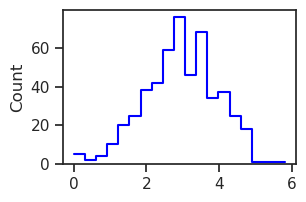

In [72]:
histplot(rate, color='b');

In [107]:
num = int(1e6)
samples = torch.empty((num, len(phi)))

for i in tqdm(range(num)):
    z = torch.poisson(rate)
    lamb = torch.exp(phi @ z)
    x = torch.poisson(lamb)
    samples[i] = x

samples.shape

100%|██████████████████████████████| 1000000/1000000 [01:03<00:00, 15696.92it/s]


torch.Size([1000000, 256])

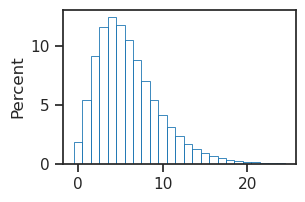

In [110]:
a = 25
bins = np.linspace(0, a, a + 1) - 0.5
histplot(samples[:, 12], element='bars', stat='percent', bins=bins);

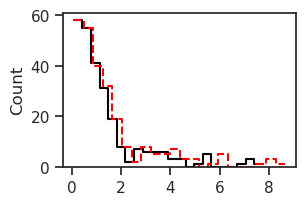

In [120]:
marginal_rates_theory = torch.exp(phi @ rate)
marginal_rates_empirical = samples.mean(0)

histplot(marginal_rates_theory, color='k')
histplot(marginal_rates_empirical, color='r', ls='--')
plt.show()

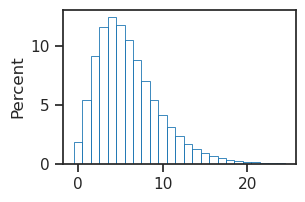

In [123]:
a = 25
pixel_i = 12

bins = np.linspace(0, a, a + 1) - 0.5
histplot(samples[:, pixel_i], element='bars', stat='percent', bins=bins);

In [128]:
def poisson_pdf(rate, max_x=20):
    xs = np.arange(0, max_x + 1)
    pmf = sp_stats.poisson.pmf(xs, rate)
    return xs, pmf

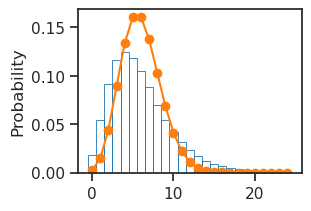

In [137]:
a = 25
pixel_i = 12
xs, ys = poisson_pdf(
    rate=marginal_rates_empirical[pixel_i].item(),
    max_x=200,
)

fig, ax = create_figure()
bins = np.linspace(0, a, a + 1) - 0.5
histplot(samples[:, pixel_i], element='bars', stat='probability', bins=bins, ax=ax)
ax.plot(xs[:a], ys[:a], marker='o')

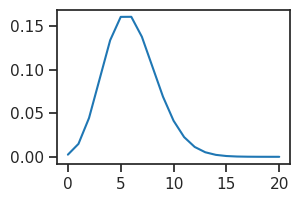

In [131]:
plt.plot(xs, pmf)

In [138]:
mu = samples.mean(0)
var = samples.var(0)

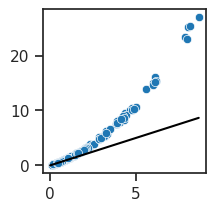

In [150]:
fig, ax = create_figure()

xs = np.linspace(0, mu.max().item())
ax.plot(xs, xs, color='k')

sns.scatterplot(x=tonp(mu), y=tonp(var))

ax_square(ax)
plt.show()

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('vH16', model_type, 'jacob|lin')
cfg_vae['cell_ratios'] = (0.0, 0.0, 1.0)
cfg_vae['n_latents'] = 512

vae = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = TrainerVAE(vae, ConfigTrainVAE(**cfg_tr), device=device)

In [4]:
vae.layer.chunk_dim

[0, 0, 512]

In [5]:
vae.layer.phi.weight.shape, vae.layer.psi.weight.shape

(torch.Size([256, 512]), torch.Size([256, 512]))

In [6]:
print_num_params(vae.layer)

+--------------+------------+
| Module Name  | Num Params |
+--------------+------------+
| PoissonLayer |  263.2 K   |
|     ———      |    ———     |
|     phi      |  131.1 K   |
|     psi      |  131.1 K   |
+--------------+------------+

In [7]:
vae.print()

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  263.2 K   |
|     ———     |    ———     |
|    layer    |  263.2 K   |
+-------------+------------+

In [8]:
x = next(iter(tr.dl_vld))[0]
x.shape

torch.Size([200, 1, 16, 16])

In [9]:
output = vae(x, return_extras=True).stack()

In [10]:
list(output)

['loss_kl',
 'loss_recon',
 'posterior',
 'ff',
 'recon',
 'state',
 'samples',
 'conditional']

<Axes: ylabel='Count'>

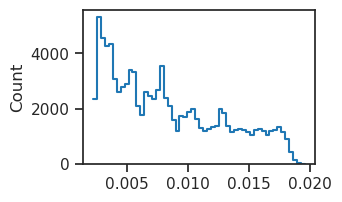

In [11]:
histplot(output['posterior']['7'].rate.ravel())

<Axes: ylabel='Count'>

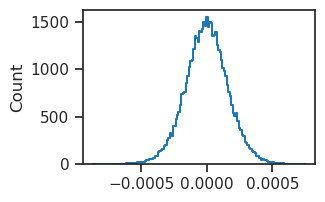

In [12]:
histplot(output['conditional']['7'].loc.ravel())

<Axes: ylabel='Count'>

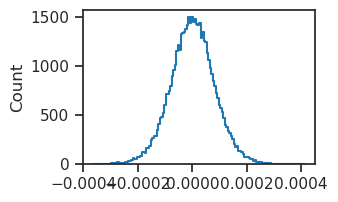

In [13]:
histplot(torch.log(output['conditional']['7'].scale).ravel())

In [14]:
{t: d.scale.min() for t, d in output['conditional'].items()}

{'0': tensor(0.9996, device='cuda:0', grad_fn=<MinBackward1>),
 '1': tensor(0.9996, device='cuda:0', grad_fn=<MinBackward1>),
 '2': tensor(0.9996, device='cuda:0', grad_fn=<MinBackward1>),
 '3': tensor(0.9996, device='cuda:0', grad_fn=<MinBackward1>),
 '4': tensor(0.9997, device='cuda:0', grad_fn=<MinBackward1>),
 '5': tensor(0.9996, device='cuda:0', grad_fn=<MinBackward1>),
 '6': tensor(0.9996, device='cuda:0', grad_fn=<MinBackward1>),
 '7': tensor(0.9996, device='cuda:0', grad_fn=<MinBackward1>)}

In [15]:
d = output['conditional']['7']

In [17]:
_x = x.flatten(start_dim=1)
_x.shape

torch.Size([200, 256])

In [19]:
d.log_prob(_x).mul(-1.0).shape

torch.Size([200, 256])

In [21]:
M = 256
extra = 0.5 * np.log(2*np.pi)

extra, M * extra

(0.9189385332046727, 235.2482645003962)

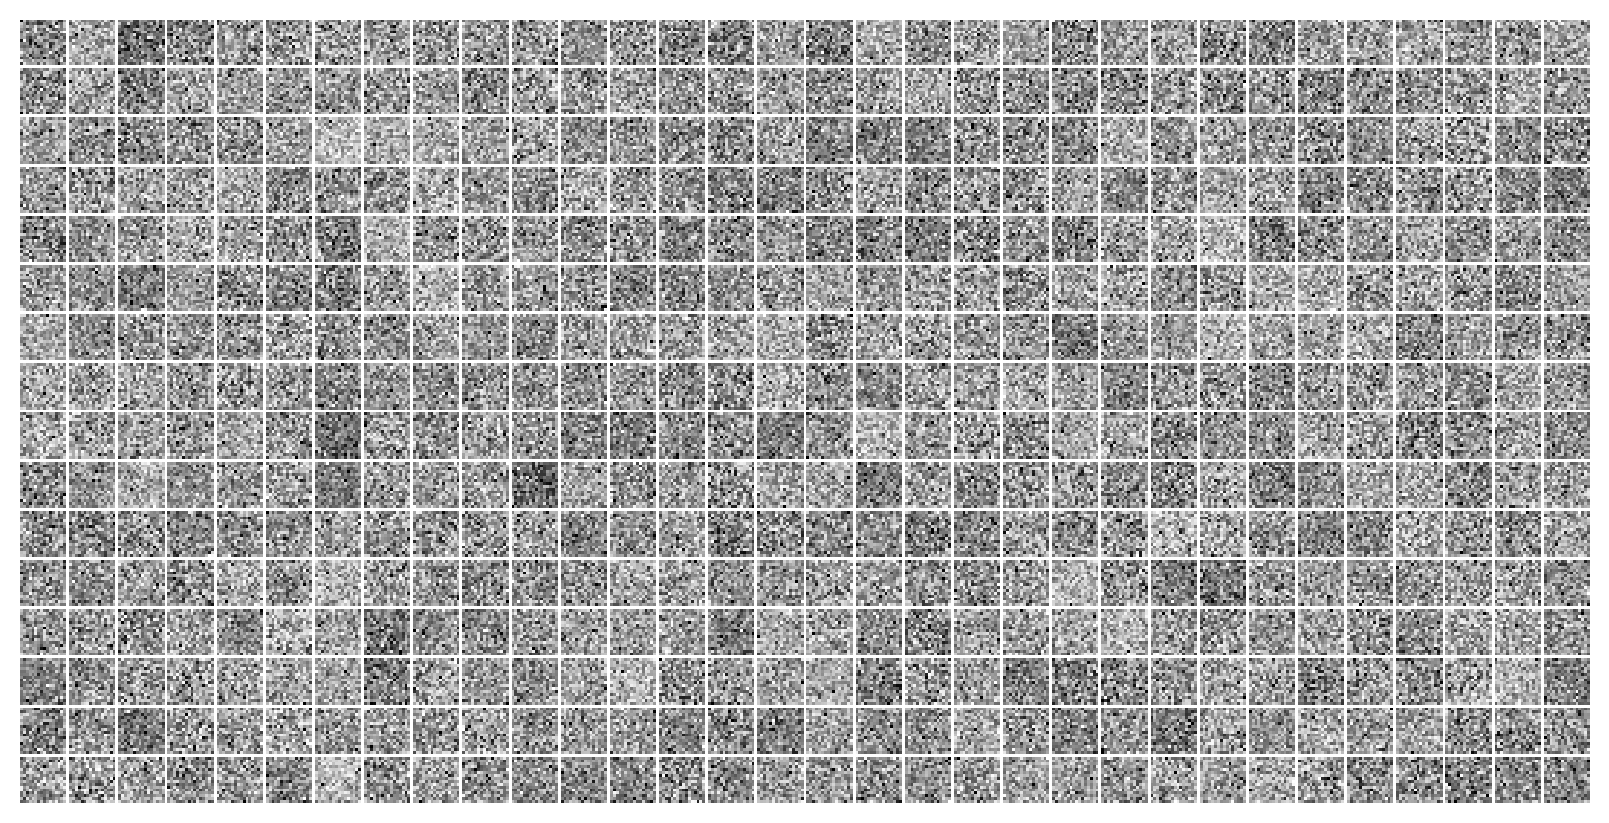

In [7]:
vae.show('phi');

<Axes: ylabel='Count'>

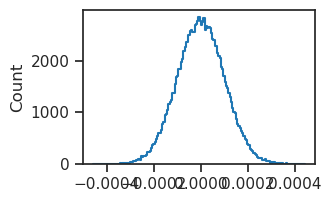

In [7]:
histplot(vae.layer.phi.weight.data.ravel())

In [8]:
vae.layer.phi.weight.data

tensor([[-2.1857e-04, -8.3428e-05,  1.9062e-05,  ..., -8.9686e-05,
          1.8294e-05, -4.2530e-06],
        [ 9.8683e-05,  2.0701e-04,  2.7912e-05,  ...,  5.1263e-05,
         -9.7520e-06,  1.8000e-04],
        [-6.6516e-05, -5.7670e-06,  4.0483e-05,  ..., -1.3485e-06,
          3.5796e-05, -7.6949e-05],
        ...,
        [-1.7779e-04, -4.0363e-05,  1.6821e-04,  ..., -9.0929e-05,
          1.8915e-04,  5.3232e-05],
        [ 1.8508e-06, -1.0854e-04, -5.6642e-05,  ..., -7.1040e-05,
          2.2080e-04,  1.8361e-04],
        [ 6.3514e-05, -4.5101e-05,  8.2687e-05,  ..., -4.9467e-05,
          2.3217e-05,  1.1327e-04]], device='cuda:0')